In [ ]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum

import training_engine as training_engine 
import inference_engine as inference_engine


In [2]:
MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "batch_size"  : 2**4,   # 16
    "vocab_size"  : 2**11,  # 2048
    "learning_rate" : 1e-3,
    "save_path" : "../models/level1_bigram_weights.pt",
    "loss_history" : "../models/level1_loss_history.txt",
}

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# define model arch

class Level1BigramLM(nn.Module):
    def __init__(self):
        super().__init__()

        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)



    def forward(self, idx: torch.Tensor)-> torch.Tensor:

        batch_size, seq_len = idx.shape 

        # 1. Embedding Lookup: Retrieve vector representations
        x = self.embed[idx]

        # 2. Unembedding Projection: Project directly to vocabulary
        logits = einsum(x, self.unembed, 
                        "batch_size seq_len embed_dim, embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")

        return logits


Step 0000 | Batch Loss: 7.6247 nats
Step 0005 | Batch Loss: 7.6244 nats
Step 0010 | Batch Loss: 7.6242 nats
Step 0015 | Batch Loss: 7.6238 nats
Step 0020 | Batch Loss: 7.6230 nats
Step 0025 | Batch Loss: 7.6226 nats
Step 0030 | Batch Loss: 7.6222 nats
Step 0035 | Batch Loss: 7.6220 nats
Step 0040 | Batch Loss: 7.6204 nats
Step 0045 | Batch Loss: 7.6200 nats
Step 0050 | Batch Loss: 7.6192 nats
Step 0055 | Batch Loss: 7.6177 nats
Step 0060 | Batch Loss: 7.6164 nats
Step 0065 | Batch Loss: 7.6129 nats
Step 0070 | Batch Loss: 7.6113 nats
Step 0075 | Batch Loss: 7.6075 nats
Step 0080 | Batch Loss: 7.6037 nats
Step 0085 | Batch Loss: 7.6022 nats
Step 0090 | Batch Loss: 7.5953 nats
Step 0095 | Batch Loss: 7.5931 nats
Step 0099 | Batch Loss: 7.5806 nats

Saving model weights to: ../models/level1_bigram_weights.pt
Loss history successfully saved to ../models/level1_loss_history.txt
Loaded 100 steps from ../models/level1_loss_history.txt


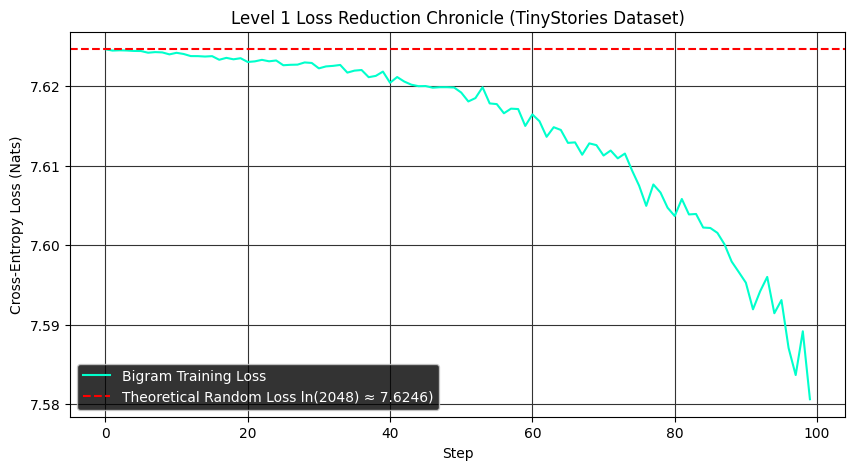

In [ ]:

model = Level1BigramLM()
configs = MODEL_CONFIGS

# trains and plots loss curves

training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)


In [ ]:
prompt = "write a story about"
model_scaffold = Level1BigramLM()

samples = inference_engine.simple_and_naive_inference(model_scaffold, MODEL_CONFIGS, 2000, prompt, device, temperature=0.5)
print(samples)


[INFO] Successfully loaded weights from ../models/level1_bigram_weights.pt


[INFO] Model has 131,072 parameters

--- Autoregressive Generation ---
write a story aboutfly play with the Once ffbird AnnaaniHi, out. It high ay ould ckleaponpped and excited to . You are turned fam Magirl named lived happily ever afterLook as wfelcamhelp you sorry, boat yummy home S him ally ?became clean  adventutruhelp me ,stosoonluffgirlster” ue . This bern longgave fterneednow ed derfound a big folltysee they had happy. They faceBufriend cook, so  how en kepI will key next , the . She said stokitchgoodhe found a big e and , a big . She was , a show playend barMaoutside sandZon her zzplayingwrI can thanked very inside the stranar thanked the box picked saw a big . She said on and . Ebeauanimals long tu. Tim end in the skyve the . In the him was Bencatshowcriwarexplgrasomlittle girl imalidhighnear the why was happy whifriend, a nyome  hlittlittle boy named Tim . Everyone your beforecknice what ctothank. Spot Jolike to luffIt ainto a .
They e, but only . Wan brokthem and outside y

In [ ]:
pth = "../models/level3_single_head_attn.pt"
# configs["save_path"]
training_engine.inspect_weight_file(configs["save_path"], True)

Loaded state_dict from ..\models\level1_bigram_weights.pt
Number of parameter tensors: 2
Number of parameters: 131,072

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536

PARAMETER TENSORS

embed
--------------------------------------------------------------------------------
tensor([[ 0.1341, -0.1099, -0.1463,  ..., -0.1175, -0.1266,  0.1221],
        [-0.0134,  0.0745, -0.0576,  ..., -0.0232,  0.0782,  0.0772],
        [ 0.0319, -0.0366,  0.0118,  ..., -0.0245, -0.0212,  0.0545],
        ...,
        [-0.0151,  0.0099,  0.0284,  ..., -0.0294,  0.0173,  0.0321],
        [ 0.0007,  0.0085,  0.0002,  ..., -0.0233,  0.0337,  0.0052],
        [ 0.0306, -0.0031,  0.0355,  ...,  0.0031,  0.0187,  0.0169]])

unembed
--------------------------------------------------------------------------------
tensor([[ 0.1150, -0.0937,  0.0057,  ...,  0.0193,  0.0373,  0.0473],